In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ZIP file path
zip_path = 'credit_card_transactions-ibm_v2.zip'

# CSV inside ZIP has the same name but .csv
csv_inside_zip = 'credit_card_transactions-ibm_v2.zip'

# Read CSV from ZIP
transactions_df = pd.read_csv(zip_path, compression='zip')

# Data Cleaning

In [3]:
transactions_df.head(10)

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2002,9,1,06:21,$134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,NaN,No
1,0,0,2002,9,1,06:42,$38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
2,0,0,2002,9,2,06:22,$120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
3,0,0,2002,9,2,17:45,$128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754.0,5651,NaN,No
4,0,0,2002,9,3,06:23,$104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750.0,5912,NaN,No
5,0,0,2002,9,3,13:53,$86.19,Swipe Transaction,-7146670748125200898,Monterey Park,CA,91755.0,5970,NaN,No
6,0,0,2002,9,4,05:51,$93.84,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
7,0,0,2002,9,4,06:09,$123.50,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
8,0,0,2002,9,5,06:14,$61.72,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
9,0,0,2002,9,5,09:35,$57.10,Swipe Transaction,4055257078481058705,La Verne,CA,91750.0,7538,NaN,No


In [4]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24386900 entries, 0 to 24386899
Data columns (total 15 columns):
 #   Column          Dtype  
---  ------          -----  
 0   User            int64  
 1   Card            int64  
 2   Year            int64  
 3   Month           int64  
 4   Day             int64  
 5   Time            object 
 6   Amount          object 
 7   Use Chip        object 
 8   Merchant Name   int64  
 9   Merchant City   object 
 10  Merchant State  object 
 11  Zip             float64
 12  MCC             int64  
 13  Errors?         object 
 14  Is Fraud?       object 
dtypes: float64(1), int64(7), object(7)
memory usage: 2.7+ GB


In [5]:
transactions_df.shape

(24386900, 15)

In [6]:
transactions_df.isna().sum()

User                     0
Card                     0
Year                     0
Month                    0
Day                      0
Time                     0
Amount                   0
Use Chip                 0
Merchant Name            0
Merchant City            0
Merchant State     2720821
Zip                2878135
MCC                      0
Errors?           23998469
Is Fraud?                0
dtype: int64

In [7]:
transactions_df.duplicated().sum()

np.int64(66)

In [8]:
transactions_df['Merchant State'].value_counts(dropna=False)

Merchant State
NaN                                 2720821
CA                                  2591830
TX                                  1793298
FL                                  1458699
NY                                  1446864
                                     ...   
Togo                                      2
Democratic Republic of the Congo          2
Kiribati                                  1
Botswana                                  1
Paraguay                                  1
Name: count, Length: 224, dtype: int64

In [9]:
transactions_df['Zip'].value_counts(dropna=False)

Zip
NaN        2878135
98516.0      55679
43830.0      48815
55024.0      44571
95076.0      43656
            ...   
71069.0          1
56447.0          1
57456.0          1
84782.0          1
56556.0          1
Name: count, Length: 27322, dtype: int64

In [10]:
# Fill missing 'Merchant State' with 'Online'
transactions_df['Merchant State'] = transactions_df['Merchant State'].fillna('Online')

# Fill missing 'Zip' with '0000'
transactions_df['Zip'] = transactions_df['Zip'].fillna('0000')

In [11]:
transactions_df['Errors?'].value_counts(dropna=False)

Errors?
NaN                                                    23998469
Insufficient Balance                                     242783
Bad PIN                                                   58918
Technical Glitch                                          48157
Bad Card Number                                           13321
Bad CVV                                                   10740
Bad Expiration                                            10716
Bad Zipcode                                                2079
Bad PIN,Insufficient Balance                                581
Insufficient Balance,Technical Glitch                       457
Bad PIN,Technical Glitch                                    128
Bad Card Number,Insufficient Balance                        122
Bad CVV,Insufficient Balance                                 89
Bad Expiration,Insufficient Balance                          78
Bad Card Number,Bad CVV                                      60
Bad Card Number,Bad Expiration  

In [12]:
# Drop the 'Errors?' column
transactions_df = transactions_df.drop(columns=['Errors?'], axis=1)

# Create 'Transaction Date' from 'Year', 'Month', 'Day'
transactions_df['Transaction Date'] = pd.to_datetime(transactions_df[['Year', 'Month', 'Day']])

# Drop the 'Year', 'Month', and 'Day' column
transactions_df = transactions_df.drop(columns=['Year', 'Month', 'Day'])

In [13]:
# Binary columns
transactions_df['Is Fraud?'] = transactions_df['Is Fraud?'].map({'Yes':1, 'No':0})
transactions_df = pd.get_dummies(transactions_df,columns=['Use Chip'], drop_first=True)

# High-cardinality columns
transactions_df['Merchant City'] = transactions_df['Merchant City'].map(transactions_df['Merchant City'].value_counts())

transactions_df['Merchant State'] = transactions_df['Merchant State'].astype('category').cat.codes

# Convert 'Amount' to float
transactions_df['Amount'] = transactions_df['Amount'].replace('[\$,]', '', regex=True).astype(float)

#Convert 'Time' to float 
transactions_df['Time'] = transactions_df['Time'].replace('[\:,]', '', regex=True).astype(float)


In [14]:
transactions_df.head(10)

,User,Card,Time,Amount,Merchant Name,Merchant City,Merchant State,Zip,MCC,Is Fraud?,Transaction Date,Use Chip_Online Transaction,Use Chip_Swipe Transaction
0,0,0,621.0,134.09,3527213246127876953,10912,28,91750.0,5300,0,2002-09-01,False,True
1,0,0,642.0,38.48,-727612092139916043,7319,28,91754.0,5411,0,2002-09-01,False,True
2,0,0,622.0,120.34,-727612092139916043,7319,28,91754.0,5411,0,2002-09-02,False,True
3,0,0,1745.0,128.95,3414527459579106770,7319,28,91754.0,5651,0,2002-09-02,False,True
4,0,0,623.0,104.71,5817218446178736267,10912,28,91750.0,5912,0,2002-09-03,False,True
5,0,0,1353.0,86.19,-7146670748125200898,7319,28,91755.0,5970,0,2002-09-03,False,True
6,0,0,551.0,93.84,-727612092139916043,7319,28,91754.0,5411,0,2002-09-04,False,True
7,0,0,609.0,123.50,-727612092139916043,7319,28,91754.0,5411,0,2002-09-04,False,True
8,0,0,614.0,61.72,-727612092139916043,7319,28,91754.0,5411,0,2002-09-05,False,True
9,0,0,935.0,57.10,4055257078481058705,10912,28,91750.0,7538,0,2002-09-05,False,True


# EDA

In [15]:
sample_df = transactions_df.sample(n=100000, random_state=42)

fraud_data = transactions_df[transactions_df['Is Fraud?'] == 1]

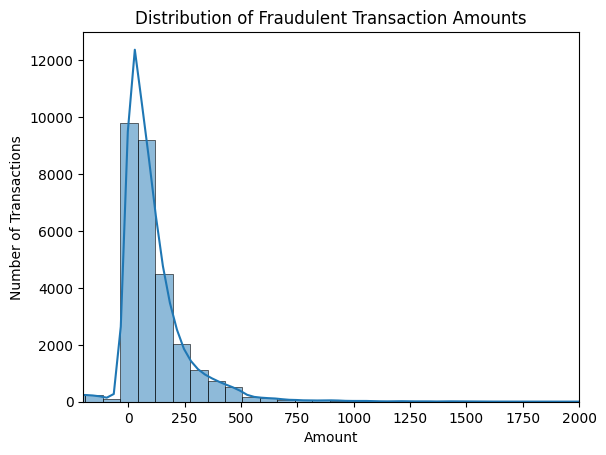

In [16]:
import seaborn as sns

sns.histplot(fraud_data['Amount'], kde=True, bins=80)
plt.title('Distribution of Fraudulent Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Number of Transactions')
plt.xlim(-200, 2000)
plt.show()

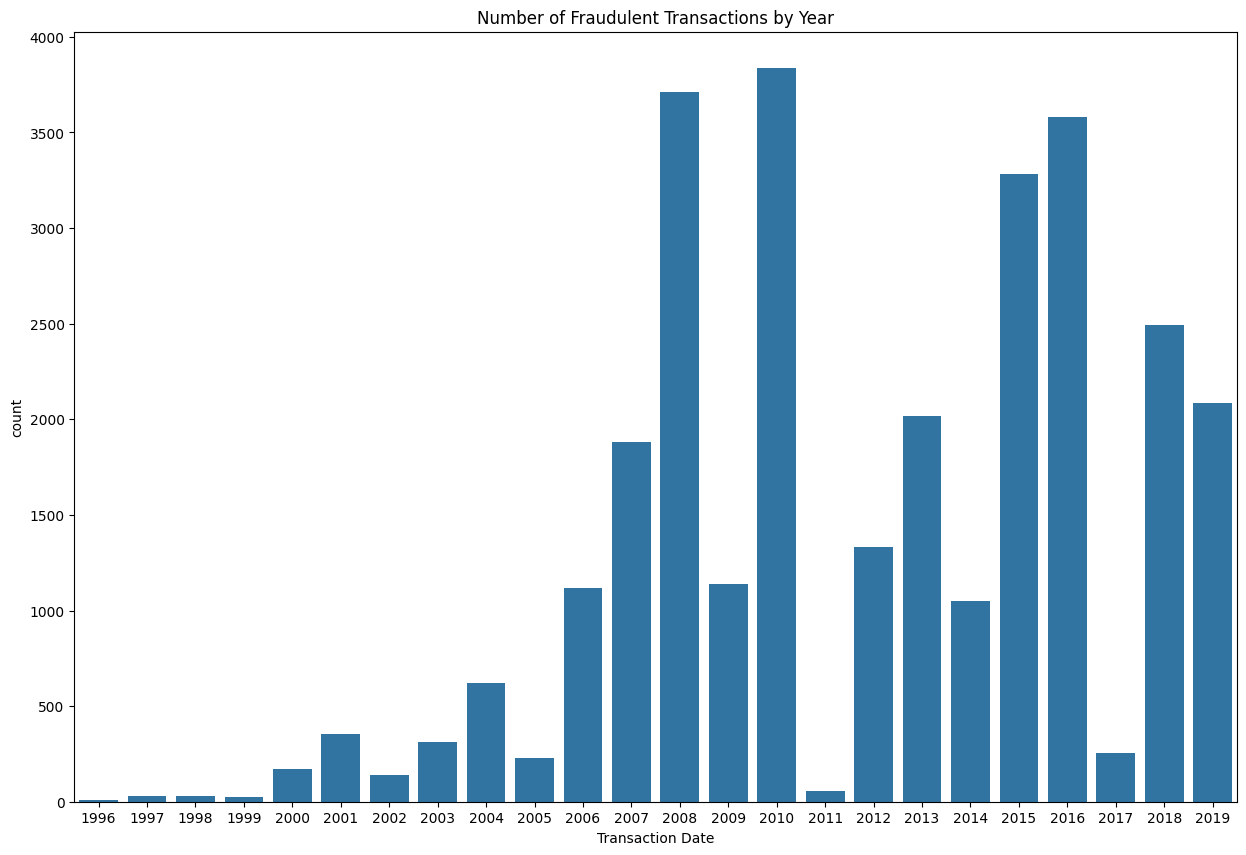

In [17]:
plt.figure(figsize=(15, 10))
sns.countplot(x=fraud_data['Transaction Date'].dt.year)
plt.title('Number of Fraudulent Transactions by Year')
plt.show()

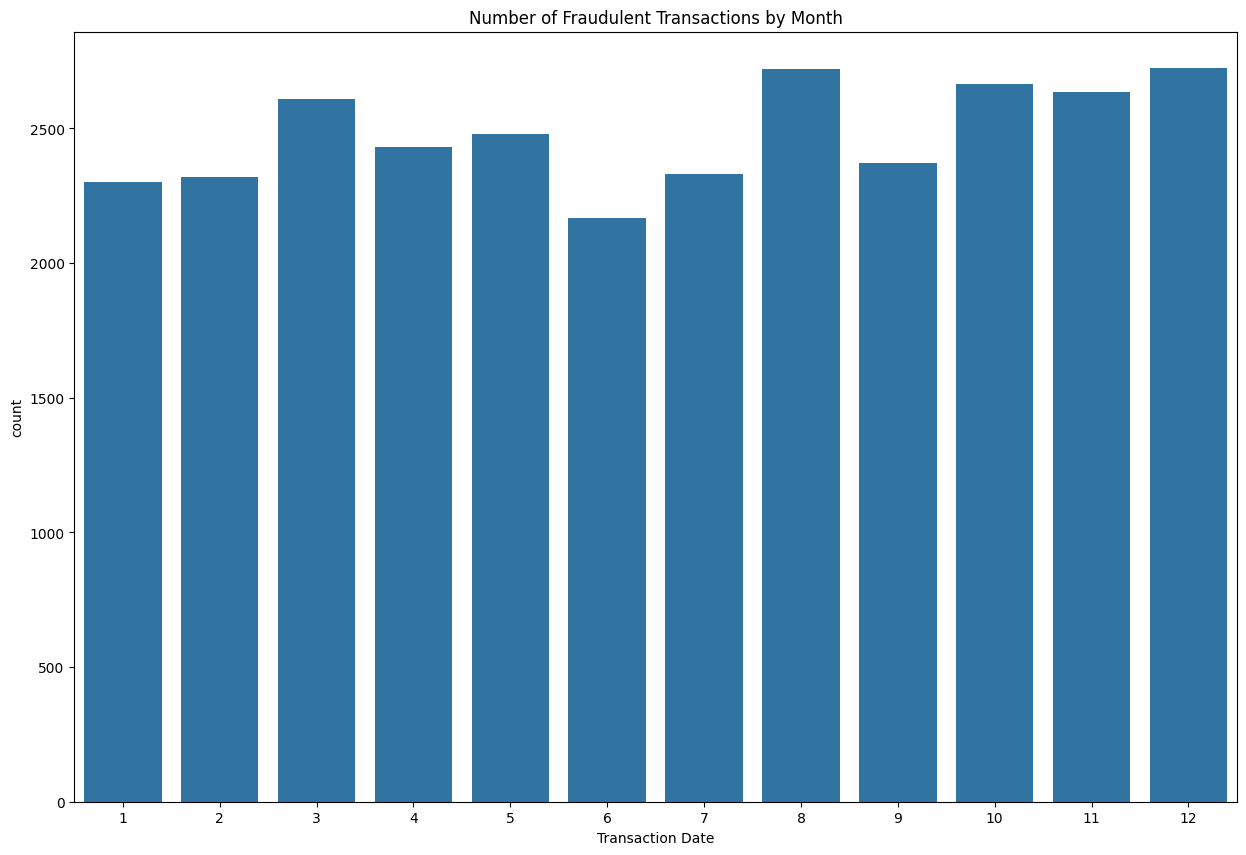

In [18]:
plt.figure(figsize=(15, 10))
sns.countplot(x=fraud_data['Transaction Date'].dt.month)
plt.title('Number of Fraudulent Transactions by Month')
plt.show()

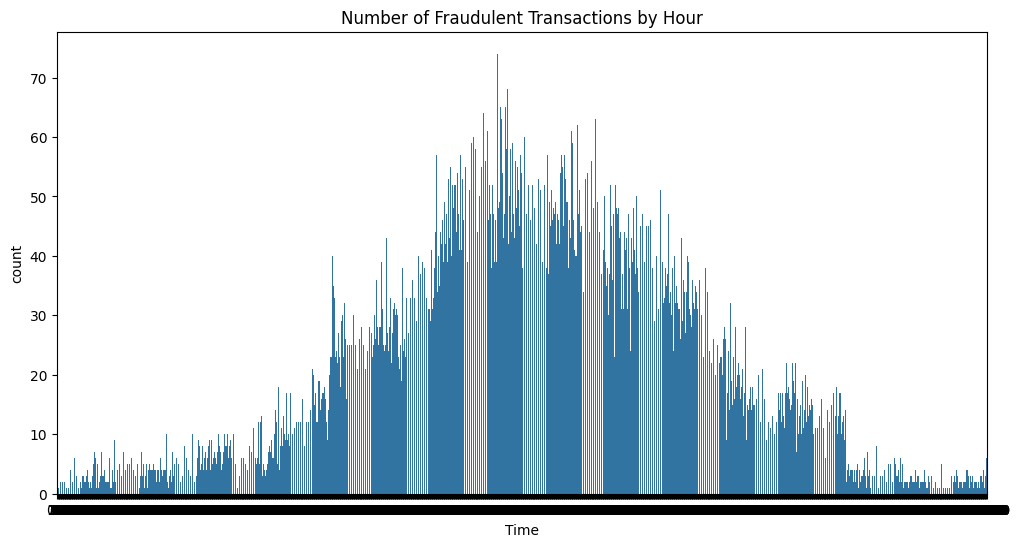

In [19]:
plt.figure(figsize=(12, 6))
sns.countplot(data=fraud_data, x=fraud_data['Time'], order=sorted(fraud_data['Time'].unique()))
plt.title('Number of Fraudulent Transactions by Hour')
plt.show()

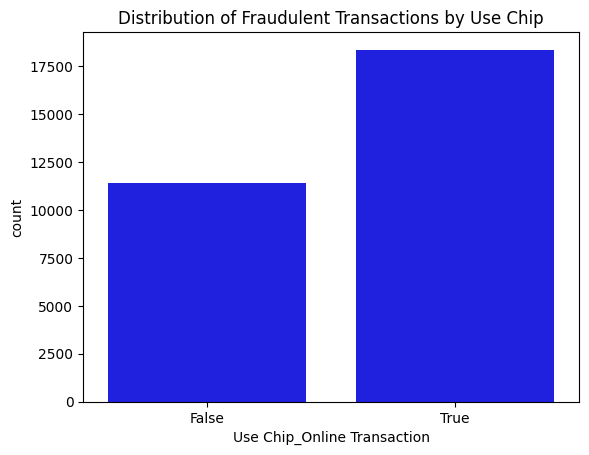

In [20]:
sns.countplot(data=fraud_data, x='Use Chip_Online Transaction', color='blue')
plt.title('Distribution of Fraudulent Transactions by Use Chip')
plt.show()

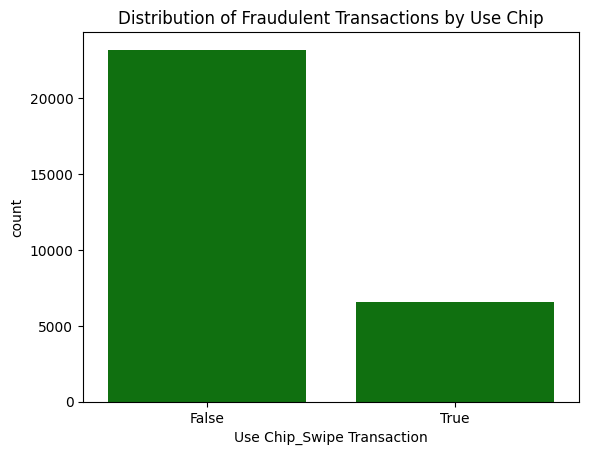

In [21]:
sns.countplot(data=fraud_data, x='Use Chip_Swipe Transaction', color='green')
plt.title('Distribution of Fraudulent Transactions by Use Chip')
plt.show()

In [22]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
import pandas as pd

# Split features and target
X = sample_df.drop(columns=['Is Fraud?'])
y = sample_df['Is Fraud?']

# Total desired samples and fraud proportion
total_samples = 40000
fraud_proportion = 0.2
fraud_samples = int(total_samples * fraud_proportion)
nonfraud_samples = total_samples - fraud_samples

# Step 1: Oversample minority (fraud) if needed
ros = RandomOverSampler(sampling_strategy={1: fraud_samples}, random_state=1613)
X_over, y_over = ros.fit_resample(X, y)

# Step 2: Undersample majority (non-fraud) to match total
rus = RandomUnderSampler(sampling_strategy={0: nonfraud_samples, 1: fraud_samples}, random_state=1613)
X_resampled, y_resampled = rus.fit_resample(X_over, y_over)

# Step 3: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.3, random_state=1613
)

# Quick sanity check
print("Total samples after resampling:", len(y_resampled))
print("Fraud cases:", sum(y_resampled))
print("Non-fraud cases:", len(y_resampled) - sum(y_resampled))

c:\Users\smzrodne\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\Users\smzrodne\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


Total samples after resampling: 40000
Fraud cases: 8000
Non-fraud cases: 32000


c:\Users\smzrodne\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:484: FutureWarning: `BaseEstimator._check_n_features` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_n_features` instead.
  warnings.warn(
c:\Users\smzrodne\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\base.py:493: FutureWarning: `BaseEstimator._check_feature_names` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation._check_feature_names` instead.
  warnings.warn(


In [23]:
# Modeling with Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred_rf = rf_classifier.predict(X_test)

print("Random Forest Classifier Results:")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

TypeError: Cannot cast DatetimeArray to dtype float32